# CESR RF-off optics in SciBmad

This notebook visualizes the RF-off nonlinear Twiss table generated by `compute_nonlinear_twiss.jl`. It plots the two normal-mode $\alpha$ and $\beta$ functions, accumulated chromaticity, first momentum derivatives, and the SciBmad closed orbit around CESR.

The source CSV is a second-order GTPSA calculation about the patched four-dimensional RF-off coasting closed orbit. These are SciBmad outputs; machine validation is a separate future step.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#3D8DFF"
CYAN = "#31B7D4"
RED = "#D1495B"
PURPLE = "#7B2CBF"
GRID = "#D9DCE1"


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\JoeyN\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


In [2]:
def find_project_root(start: Path) -> Path:
    """Find the CESR Project directory from common notebook launch locations."""
    candidates = [start, *start.parents]
    for candidate in candidates:
        direct = candidate / "bmad_comparison" / "nonlinear_twiss" / "RF_off" / "nonlinear_twiss.csv"
        nested = candidate / "CESR Project" / "bmad_comparison" / "nonlinear_twiss" / "RF_off" / "nonlinear_twiss.csv"
        if direct.exists():
            return candidate
        if nested.exists():
            return candidate / "CESR Project"
    raise FileNotFoundError("Could not locate CESR Project/nonlinear_twiss.csv")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "bmad_comparison" / "nonlinear_twiss" / "RF_off" / "nonlinear_twiss.csv"
FIGURE_DIR = PROJECT_ROOT / "bmad_comparison" / "nonlinear_twiss" / "RF_off" / "notebook_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

data = pd.read_csv(DATA_PATH)
required = {
    "s_m", "beta_1_m", "beta_2_m", "alpha_1", "alpha_2",
    "accumulated_chromaticity_1", "accumulated_chromaticity_2",
    "dbeta_1_ddelta_m", "dbeta_2_ddelta_m",
    "dalpha_1_ddelta", "dalpha_2_ddelta", "orbit_x_m", "orbit_y_m",
}
missing = sorted(required.difference(data.columns))
if missing:
    raise ValueError(f"The RF-off table is missing required columns: {missing}")

summary = pd.DataFrame({
    "quantity": ["samples", "circumference [m]", "Q1", "Q2", "xi1", "xi2"],
    "value": [
        len(data), data["s_m"].max(), data["tune_1"].iloc[0], data["tune_2"].iloc[0],
        data["chromaticity_1"].iloc[0], data["chromaticity_2"].iloc[0],
    ],
})
print(f"Loaded: {DATA_PATH}")
display(summary.assign(value=summary["value"].map(lambda value: f"{value:.9g}")))

Loaded: D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\CESR Project\bmad_comparison\nonlinear_twiss\RF_off\nonlinear_twiss.csv


,quantity,value
0,samples,1344
1,circumference [m],768.426421
2,Q1,-0.469846098
3,Q2,-0.420923757
4,xi1,-1.17233782
5,xi2,-0.966075323


## Normal-mode $\beta$ and $\alpha$

The two curves are the coupled normal modes reported by SciBmad, rather than an assumption that the machine is exactly uncoupled.

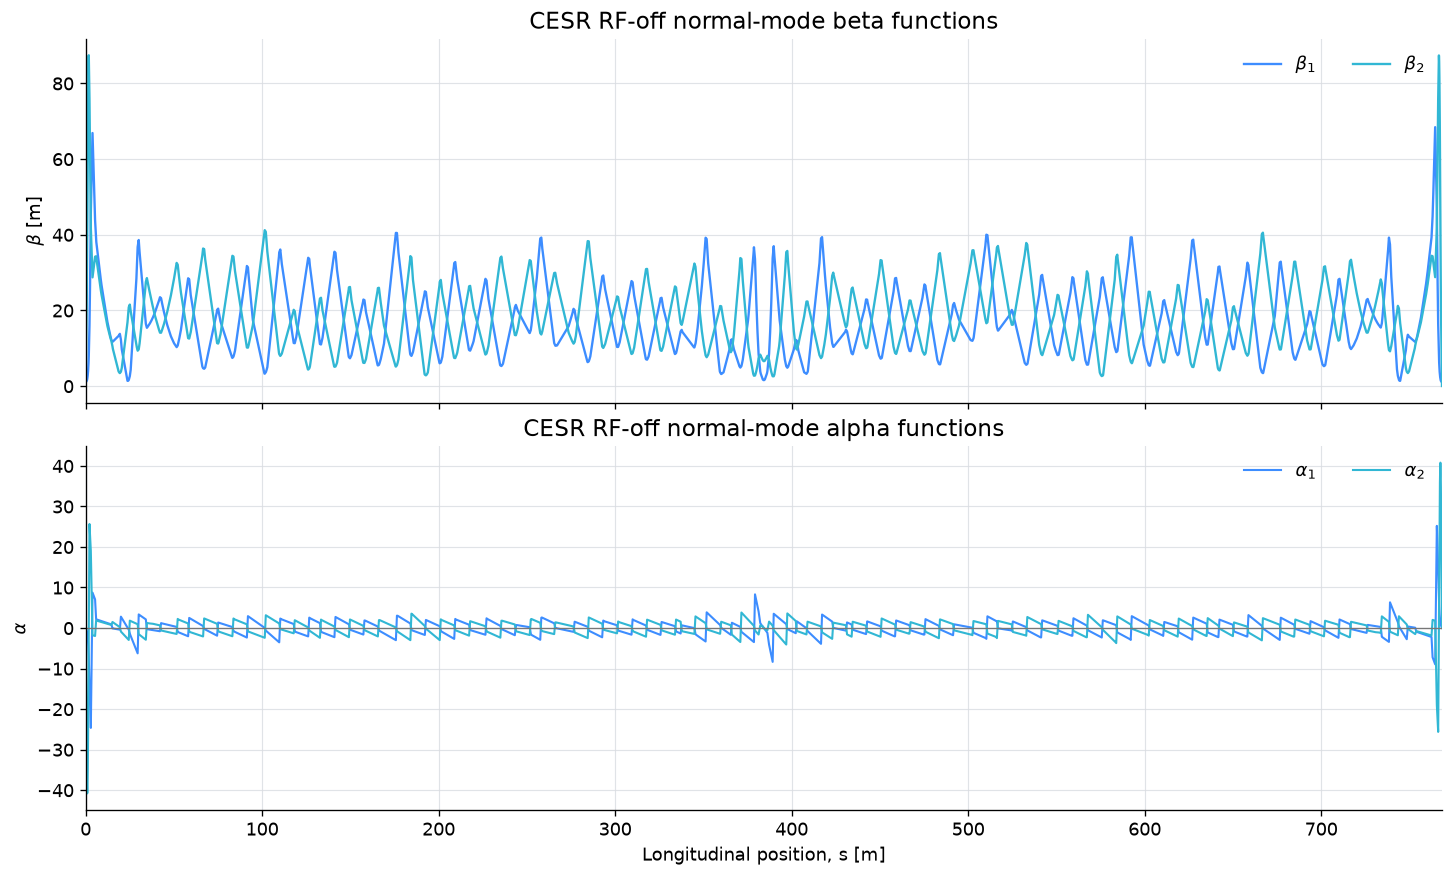

D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\CESR Project\bmad_comparison\nonlinear_twiss\RF_off\notebook_figures\rf_off_beta_alpha.png


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True, constrained_layout=True)

axes[0].plot(data["s_m"], data["beta_1_m"], color=BLUE, lw=1.4, label=r"$\beta_1$")
axes[0].plot(data["s_m"], data["beta_2_m"], color=CYAN, lw=1.4, label=r"$\beta_2$")
axes[0].set_ylabel(r"$\beta$ [m]")
axes[0].set_title("CESR RF-off normal-mode beta functions")
axes[0].legend(ncol=2)

axes[1].plot(data["s_m"], data["alpha_1"], color=BLUE, lw=1.25, label=r"$\alpha_1$")
axes[1].plot(data["s_m"], data["alpha_2"], color=CYAN, lw=1.25, label=r"$\alpha_2$")
axes[1].axhline(0, color="#777777", lw=0.8)
axes[1].set_xlabel("Longitudinal position, s [m]")
axes[1].set_ylabel(r"$\alpha$")
axes[1].set_title("CESR RF-off normal-mode alpha functions")
axes[1].legend(ncol=2)

for ax in axes:
    ax.grid(True, color=GRID, lw=0.7, alpha=0.8)
    ax.set_xlim(data["s_m"].min(), data["s_m"].max())

beta_alpha_path = FIGURE_DIR / "rf_off_beta_alpha.png"
fig.savefig(beta_alpha_path, bbox_inches="tight", facecolor="white")
plt.show()
print(beta_alpha_path)

## Accumulated chromaticity

SciBmad stores phase in turns. Therefore $d\phi_i/d\delta$ evaluated at the end of the ring equals the global chromaticity $dQ_i/d\delta$.

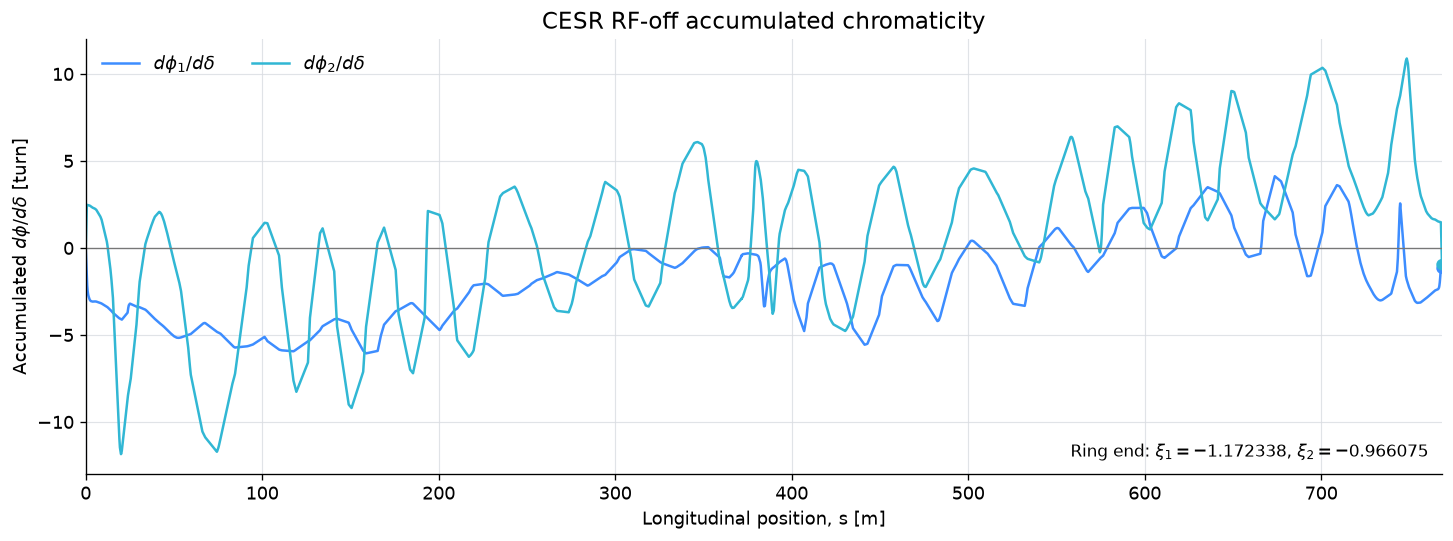

D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\CESR Project\bmad_comparison\nonlinear_twiss\RF_off\notebook_figures\rf_off_chromaticity.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 4.4), constrained_layout=True)
ax.plot(data["s_m"], data["accumulated_chromaticity_1"], color=BLUE, lw=1.5, label=r"$d\phi_1/d\delta$")
ax.plot(data["s_m"], data["accumulated_chromaticity_2"], color=CYAN, lw=1.5, label=r"$d\phi_2/d\delta$")
ax.axhline(0, color="#777777", lw=0.8)
ax.scatter([data["s_m"].iloc[-1]] * 2,
           [data["accumulated_chromaticity_1"].iloc[-1], data["accumulated_chromaticity_2"].iloc[-1]],
           color=[BLUE, CYAN], s=34, zorder=3)
ax.set_xlim(data["s_m"].min(), data["s_m"].max())
ax.set_xlabel("Longitudinal position, s [m]")
ax.set_ylabel(r"Accumulated $d\phi/d\delta$ [turn]")
ax.set_title("CESR RF-off accumulated chromaticity")
ax.grid(True, color=GRID, lw=0.7, alpha=0.8)
ax.legend(ncol=2)

xi_text = (
    rf"Ring end: $\xi_1={data['chromaticity_1'].iloc[0]:.6f}$, "
    rf"$\xi_2={data['chromaticity_2'].iloc[0]:.6f}$"
)
ax.text(0.99, 0.03, xi_text, transform=ax.transAxes, ha="right", va="bottom", fontsize=10)

chromaticity_path = FIGURE_DIR / "rf_off_chromaticity.png"
fig.savefig(chromaticity_path, bbox_inches="tight", facecolor="white")
plt.show()
print(chromaticity_path)

## First momentum derivatives of the Twiss functions

These derivatives come from a second-order GTPSA map; they are not finite-difference scans.

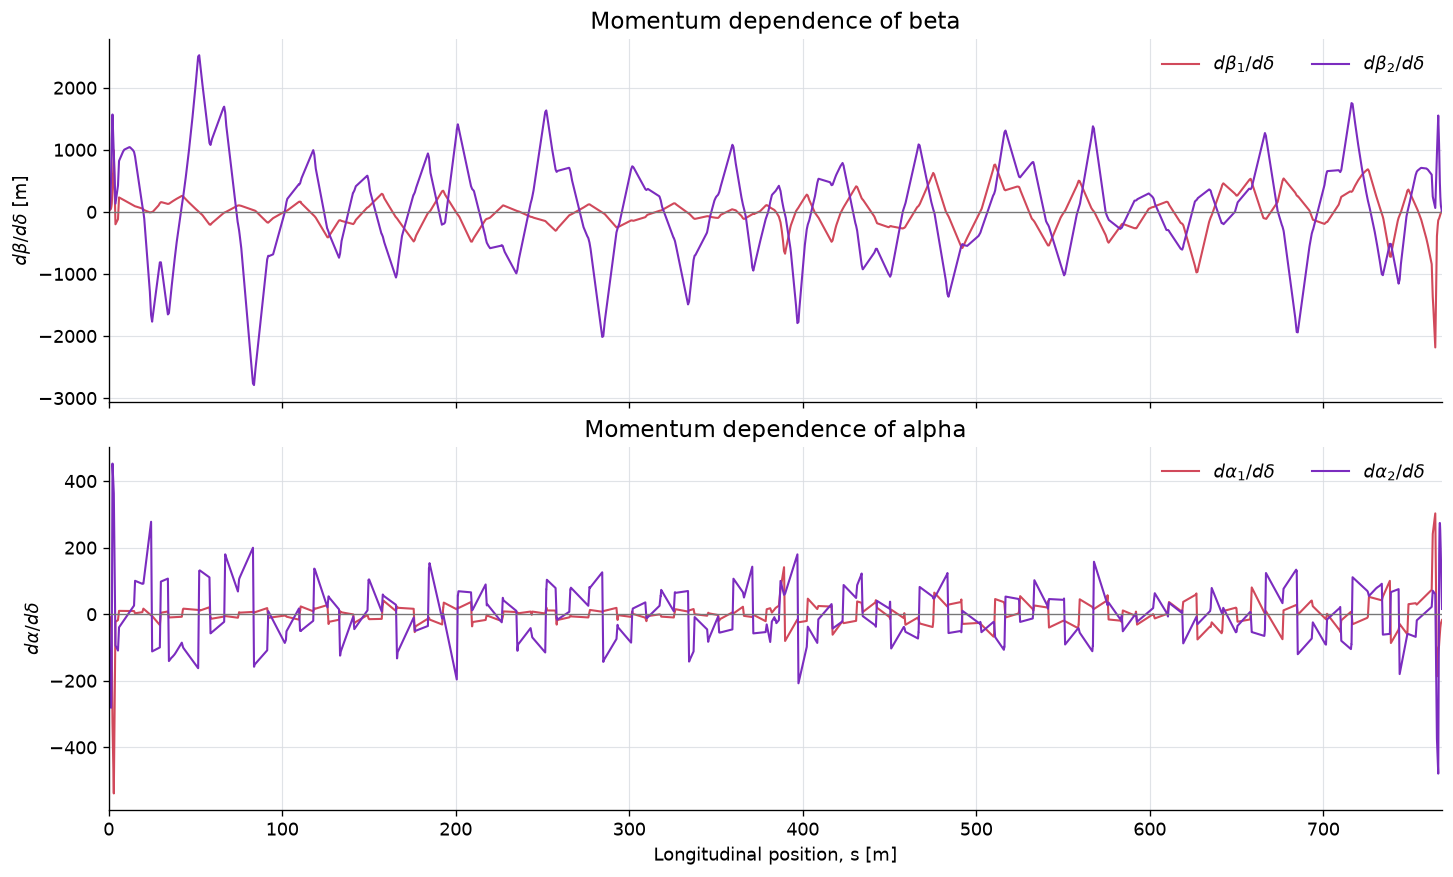

D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\CESR Project\bmad_comparison\nonlinear_twiss\RF_off\notebook_figures\rf_off_twiss_derivatives.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True, constrained_layout=True)

axes[0].plot(data["s_m"], data["dbeta_1_ddelta_m"], color=RED, lw=1.25, label=r"$d\beta_1/d\delta$")
axes[0].plot(data["s_m"], data["dbeta_2_ddelta_m"], color=PURPLE, lw=1.25, label=r"$d\beta_2/d\delta$")
axes[0].set_ylabel(r"$d\beta/d\delta$ [m]")
axes[0].set_title("Momentum dependence of beta")
axes[0].legend(ncol=2)

axes[1].plot(data["s_m"], data["dalpha_1_ddelta"], color=RED, lw=1.25, label=r"$d\alpha_1/d\delta$")
axes[1].plot(data["s_m"], data["dalpha_2_ddelta"], color=PURPLE, lw=1.25, label=r"$d\alpha_2/d\delta$")
axes[1].set_xlabel("Longitudinal position, s [m]")
axes[1].set_ylabel(r"$d\alpha/d\delta$")
axes[1].set_title("Momentum dependence of alpha")
axes[1].legend(ncol=2)

for ax in axes:
    ax.axhline(0, color="#777777", lw=0.8)
    ax.grid(True, color=GRID, lw=0.7, alpha=0.8)
    ax.set_xlim(data["s_m"].min(), data["s_m"].max())

derivatives_path = FIGURE_DIR / "rf_off_twiss_derivatives.png"
fig.savefig(derivatives_path, bbox_inches="tight", facecolor="white")
plt.show()
print(derivatives_path)

## RF-off SciBmad closed orbit

The orbit is the constant part of the normal-form orbit stored in the same Twiss table. Horizontal and vertical curves use separate axes because their scales differ substantially.

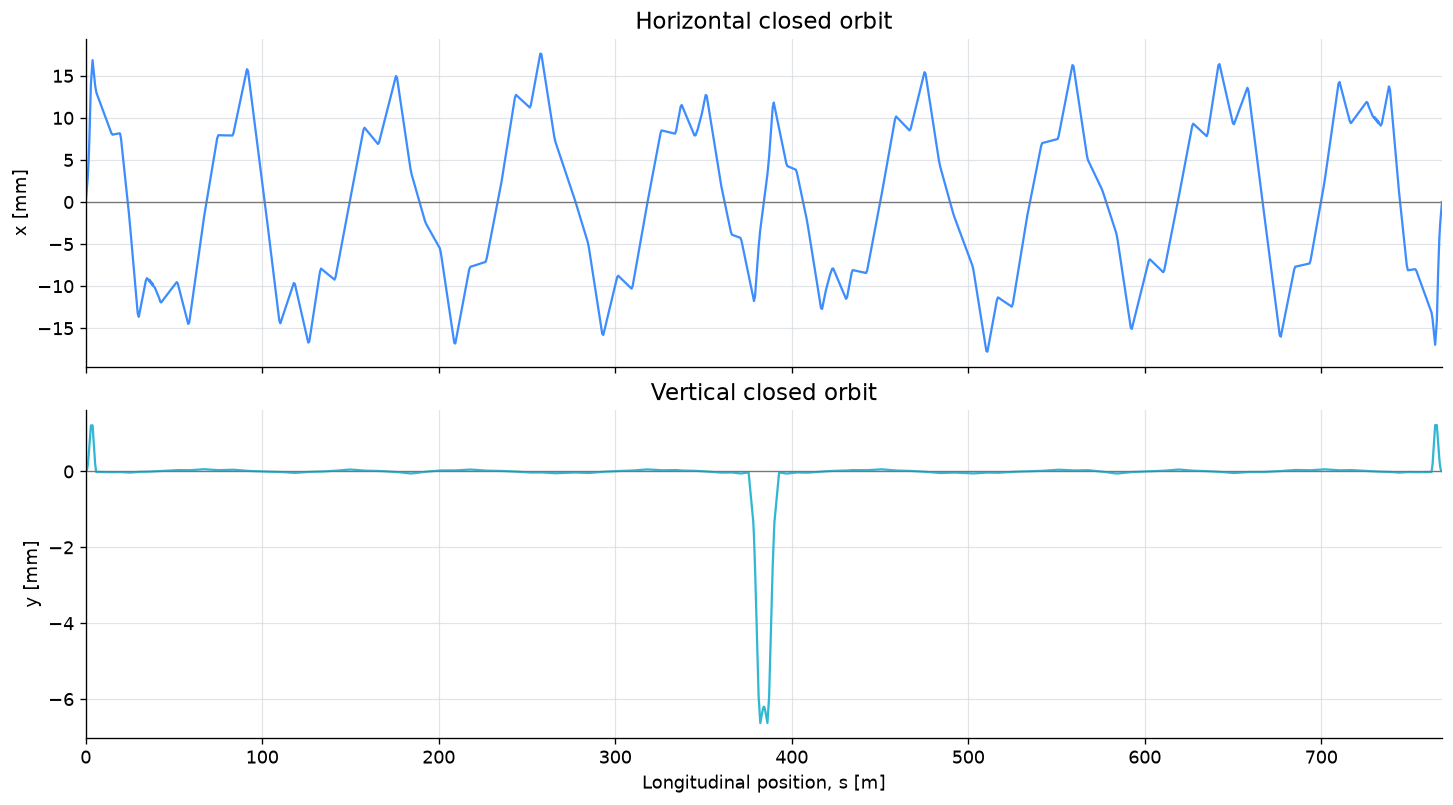

D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\CESR Project\bmad_comparison\nonlinear_twiss\RF_off\notebook_figures\rf_off_closed_orbit.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.6), sharex=True, constrained_layout=True)

axes[0].plot(data["s_m"], 1e3 * data["orbit_x_m"], color=BLUE, lw=1.35)
axes[0].set_ylabel("x [mm]")
axes[0].set_title("Horizontal closed orbit")

axes[1].plot(data["s_m"], 1e3 * data["orbit_y_m"], color=CYAN, lw=1.35)
axes[1].set_xlabel("Longitudinal position, s [m]")
axes[1].set_ylabel("y [mm]")
axes[1].set_title("Vertical closed orbit")

for ax in axes:
    ax.axhline(0, color="#777777", lw=0.8)
    ax.grid(True, color=GRID, lw=0.7, alpha=0.8)
    ax.set_xlim(data["s_m"].min(), data["s_m"].max())

orbit_path = FIGURE_DIR / "rf_off_closed_orbit.png"
fig.savefig(orbit_path, bbox_inches="tight", facecolor="white")
plt.show()
print(orbit_path)

## Reproducing the source data

From the `CESR Project` directory:

```console
julia --project=. bmad_comparison/nonlinear_twiss/compute_nonlinear_twiss.jl
```

The calculation turns all four RF cavities off, solves the four-dimensional coasting closed orbit, and evaluates a second-order GTPSA Twiss table at every saved longitudinal position.